# From 1 Feature to Many — Why We Need a New Approach

We know how to find the best slope for 1 feature. What changes when we have 2?

## Chapter 1: One feature was a line. Two features is a surface.

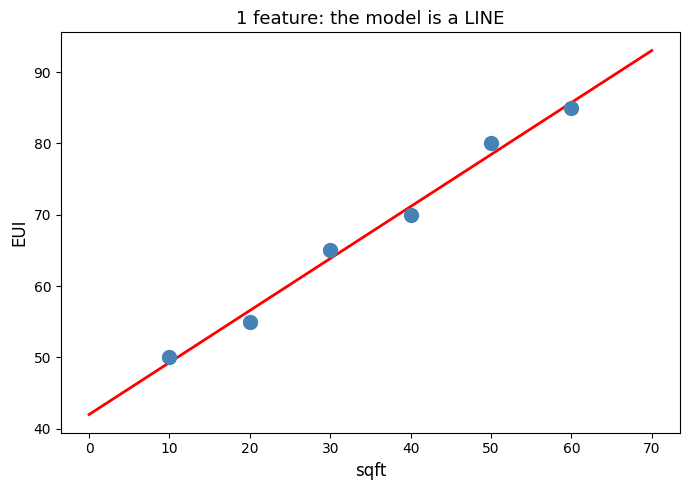

1 feature (sqft) → 2D chart → model is a LINE
prediction = slope x sqft + intercept
We found 1 slope.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# With 1 feature, we had a 2D chart: sqft on x-axis, EUI on y-axis
# The model was a LINE through the points

sqft_1d = np.array([10, 20, 30, 40, 50, 60], dtype=float)
eui_1d  = np.array([50, 55, 65, 70, 80, 85], dtype=float)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sqft_1d, eui_1d, color='steelblue', s=100, zorder=5)
x_line = np.linspace(0, 70, 100)
ax.plot(x_line, 0.729 * x_line + 42.0, color='red', linewidth=2)
ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title('1 feature: the model is a LINE', fontsize=13)
plt.tight_layout()
plt.show()

print('1 feature (sqft) → 2D chart → model is a LINE')
print('prediction = slope x sqft + intercept')
print('We found 1 slope.')

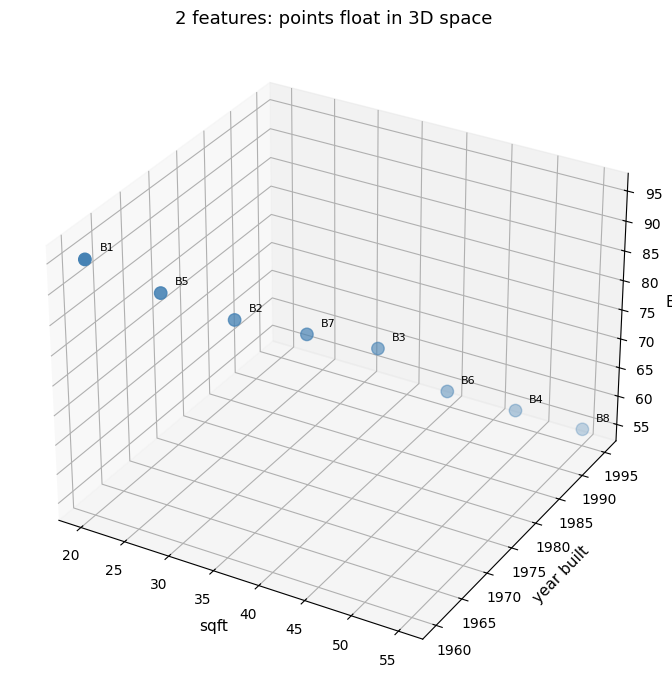

2 features (sqft + year_built) → 3D chart
The model will be a flat SURFACE (plane) through these points.
prediction = slope1 x sqft + slope2 x year_built + intercept
We need to find 2 slopes now.


In [2]:
# With 2 features, we have a 3D chart:
#   x-axis = sqft
#   y-axis = year_built  
#   z-axis = EUI (what we predict)
# The model is a FLAT SURFACE (plane) through the points

# 8 buildings with sqft AND year_built
sqft       = np.array([20, 30, 40, 50, 25, 45, 35, 55], dtype=float)
year_built = np.array([1960, 1970, 1980, 1990, 1965, 1985, 1975, 1995], dtype=float)
eui        = np.array([95, 82, 74, 60, 88, 65, 78, 55], dtype=float)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sqft, year_built, eui, color='steelblue', s=80, zorder=5)

for i in range(len(sqft)):
    ax.text(sqft[i]+1, year_built[i]+1, eui[i]+1, f'B{i+1}', fontsize=8)

ax.set_xlabel('sqft', fontsize=11)
ax.set_ylabel('year built', fontsize=11)
ax.set_zlabel('EUI', fontsize=11)
ax.set_title('2 features: points float in 3D space', fontsize=13)
plt.tight_layout()
plt.show()

print('2 features (sqft + year_built) → 3D chart')
print('The model will be a flat SURFACE (plane) through these points.')
print('prediction = slope1 x sqft + slope2 x year_built + intercept')
print('We need to find 2 slopes now.')

## Chapter 2: Can we just find each slope separately?

We know how to find the best slope for 1 feature. Why not just do it twice — once for sqft, once for year_built?

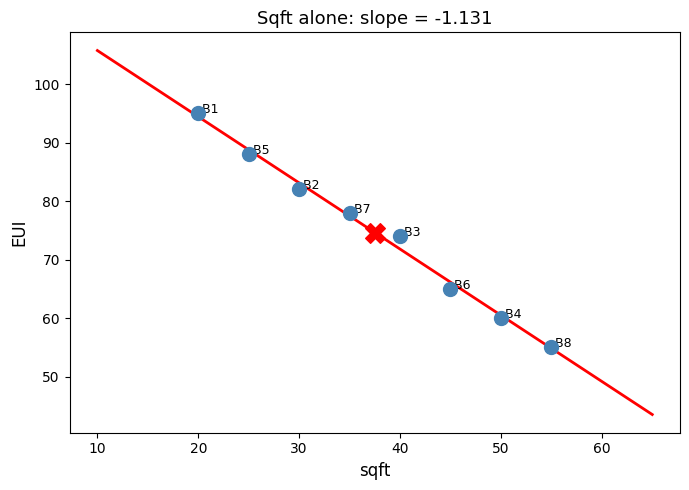

Slope for sqft (ignoring year_built): -1.131
This says: for every 1 sqft increase, EUI changes by this much.
But is this the TRUE effect of sqft? Or is year_built hiding in here too?


In [3]:
# Let's try: find slope for sqft alone, ignoring year_built

avg_sqft = sqft.mean()
avg_eui = eui.mean()

runs_sqft = sqft - avg_sqft
rises = eui - avg_eui

slope_sqft_alone = (runs_sqft * rises).sum() / (runs_sqft ** 2).sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sqft, eui, color='steelblue', s=100, zorder=5)
ax.scatter(avg_sqft, avg_eui, color='red', s=200, marker='X', zorder=5)
x_line = np.linspace(10, 65, 100)
ax.plot(x_line, slope_sqft_alone * (x_line - avg_sqft) + avg_eui, color='red', linewidth=2)
for i in range(len(sqft)):
    ax.annotate(f' B{i+1}', xy=(sqft[i], eui[i]), fontsize=9)
ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title(f'Sqft alone: slope = {slope_sqft_alone:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Slope for sqft (ignoring year_built): {slope_sqft_alone:.3f}')
print('This says: for every 1 sqft increase, EUI changes by this much.')
print('But is this the TRUE effect of sqft? Or is year_built hiding in here too?')

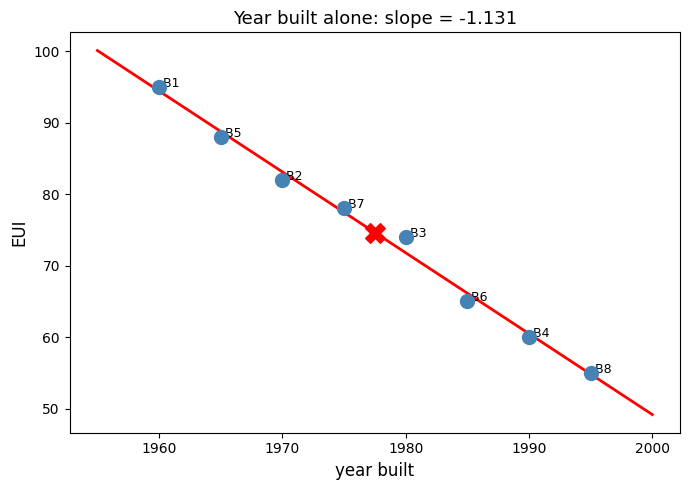

Slope for year_built (ignoring sqft): -1.131
This says: for every 1 year newer, EUI changes by this much.


In [4]:
# Find slope for year_built alone, ignoring sqft

avg_year = year_built.mean()

runs_year = year_built - avg_year

slope_year_alone = (runs_year * rises).sum() / (runs_year ** 2).sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(year_built, eui, color='steelblue', s=100, zorder=5)
ax.scatter(avg_year, avg_eui, color='red', s=200, marker='X', zorder=5)
x_line = np.linspace(1955, 2000, 100)
ax.plot(x_line, slope_year_alone * (x_line - avg_year) + avg_eui, color='red', linewidth=2)
for i in range(len(sqft)):
    ax.annotate(f' B{i+1}', xy=(year_built[i], eui[i]), fontsize=9)
ax.set_xlabel('year built', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title(f'Year built alone: slope = {slope_year_alone:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Slope for year_built (ignoring sqft): {slope_year_alone:.3f}')
print('This says: for every 1 year newer, EUI changes by this much.')

## Chapter 3: The problem — features can be related to each other

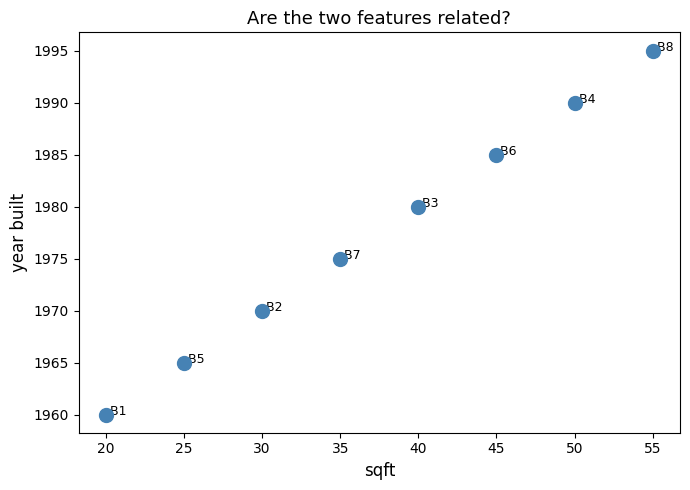

Correlation between sqft and year_built: 1.000

They ARE related! Bigger buildings tend to be newer (or vice versa).
This is the problem.

When two features are related, their effects get TANGLED.
The sqft slope we found earlier might be partly caused by year_built.


In [5]:
# Are sqft and year_built related in our data?

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sqft, year_built, color='steelblue', s=100, zorder=5)
for i in range(len(sqft)):
    ax.annotate(f' B{i+1}', xy=(sqft[i], year_built[i]), fontsize=9)
ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('year built', fontsize=12)
ax.set_title('Are the two features related?', fontsize=13)
plt.tight_layout()
plt.show()

corr = np.corrcoef(sqft, year_built)[0, 1]
print(f'Correlation between sqft and year_built: {corr:.3f}')
print()
if abs(corr) > 0.5:
    print('They ARE related! Bigger buildings tend to be newer (or vice versa).')
    print('This is the problem.')
else:
    print('They are somewhat related.')
print()
print('When two features are related, their effects get TANGLED.')
print('The sqft slope we found earlier might be partly caused by year_built.')

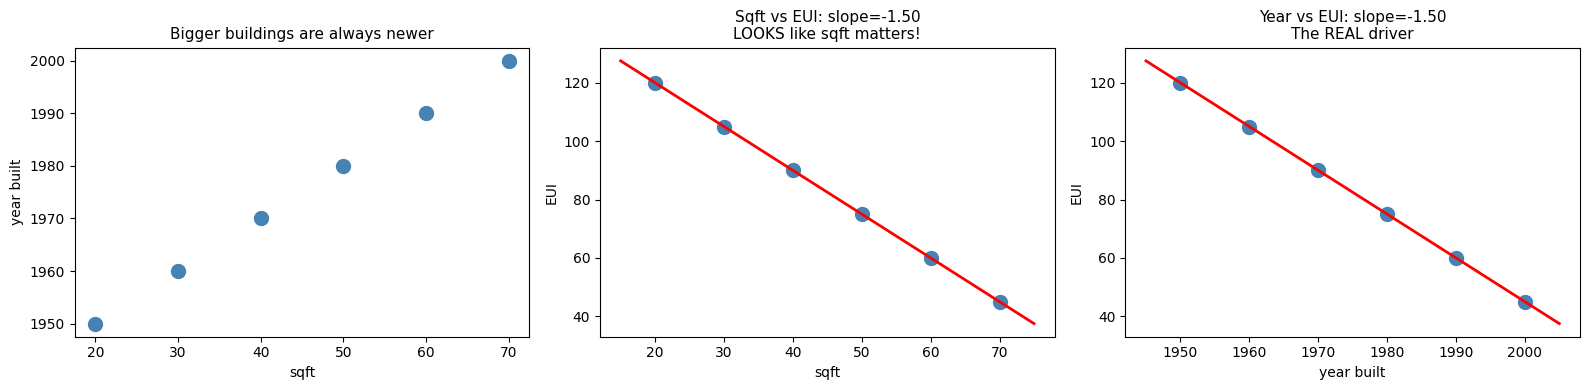

The middle chart says bigger buildings use less energy (slope = -1.50).
But that's a LIE. Size has nothing to do with it.
Bigger buildings just happen to be newer, and newer = less energy.

This is why finding slopes one at a time gives WRONG answers.
We need to untangle the features — find each slope WHILE accounting for the other.


In [6]:
# Let's make this concrete with an extreme example.
#
# Imagine: newer buildings are always bigger.
# And newer buildings use less energy (better insulation).
#
# If you look at sqft alone, you'd think:
#   "bigger buildings use less energy!"
# But that's WRONG. It's not the size — it's the age.
# Bigger buildings just happen to be newer.

# Extreme example: sqft and year perfectly correlated
ex_sqft = np.array([20, 30, 40, 50, 60, 70], dtype=float)
ex_year = np.array([1950, 1960, 1970, 1980, 1990, 2000], dtype=float)
# EUI driven ONLY by year (newer = less energy), sqft has NO real effect
ex_eui  = np.array([120, 105, 90, 75, 60, 45], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# sqft vs year: perfectly related
axes[0].scatter(ex_sqft, ex_year, color='steelblue', s=100)
axes[0].set_xlabel('sqft')
axes[0].set_ylabel('year built')
axes[0].set_title('Bigger buildings are always newer', fontsize=11)

# sqft vs EUI: looks like sqft matters!
axes[1].scatter(ex_sqft, ex_eui, color='steelblue', s=100)
avg_ex_sqft = ex_sqft.mean()
avg_ex_eui = ex_eui.mean()
ex_runs = ex_sqft - avg_ex_sqft
ex_rises = ex_eui - avg_ex_eui
ex_slope = (ex_runs * ex_rises).sum() / (ex_runs ** 2).sum()
x_line = np.linspace(15, 75, 100)
axes[1].plot(x_line, ex_slope * (x_line - avg_ex_sqft) + avg_ex_eui, 'r-', linewidth=2)
axes[1].set_xlabel('sqft')
axes[1].set_ylabel('EUI')
axes[1].set_title(f'Sqft vs EUI: slope={ex_slope:.2f}\nLOOKS like sqft matters!', fontsize=11)

# year vs EUI: the real driver
axes[2].scatter(ex_year, ex_eui, color='steelblue', s=100)
avg_ex_year = ex_year.mean()
ex_runs_y = ex_year - avg_ex_year
ex_slope_y = (ex_runs_y * ex_rises).sum() / (ex_runs_y ** 2).sum()
x_line_y = np.linspace(1945, 2005, 100)
axes[2].plot(x_line_y, ex_slope_y * (x_line_y - avg_ex_year) + avg_ex_eui, 'r-', linewidth=2)
axes[2].set_xlabel('year built')
axes[2].set_ylabel('EUI')
axes[2].set_title(f'Year vs EUI: slope={ex_slope_y:.2f}\nThe REAL driver', fontsize=11)

plt.tight_layout()
plt.show()

print('The middle chart says bigger buildings use less energy (slope = -1.50).')
print('But that\'s a LIE. Size has nothing to do with it.')
print('Bigger buildings just happen to be newer, and newer = less energy.')
print()
print('This is why finding slopes one at a time gives WRONG answers.')
print('We need to untangle the features — find each slope WHILE accounting for the other.')

## Chapter 4: The fix — find both slopes at the same time

We need to ask: "what is the effect of sqft AFTER removing the effect of year_built?" and vice versa. Both slopes must be found together.

In [7]:
# Back to our 8 buildings. Let's find both slopes simultaneously.
#
# With 1 feature, each building voted: rise / run → one slope
# With 2 features, each building has TWO runs: one in sqft, one in year_built
# We need to figure out how much of the rise was caused by EACH run.
#
# Think of it this way:
# Building 1 has EUI 20 above average.
# It also has sqft 15 above average AND year_built 10 below average.
# How much of that +20 EUI was because of sqft? How much because of year_built?

print('The question for each building:')
print()
print('Building | sqft run | year run | EUI rise | ???')
print('-' * 60)
for i in range(len(sqft)):
    print(f'   B{i+1}    | {runs_sqft[i]:+7.1f}  | {runs_year[i]:+7.0f}  | {rises[i]:+7.1f}  | how to split?')

print()
print('Each building\'s EUI rise is caused by BOTH features together.')
print('We can\'t just divide rise by one run — the other run is also contributing.')
print()
print('We need to solve for both slopes AT THE SAME TIME.')

The question for each building:

Building | sqft run | year run | EUI rise | ???
------------------------------------------------------------
   B1    |   -17.5  |     -18  |   +20.4  | how to split?
   B2    |    -7.5  |      -8  |    +7.4  | how to split?
   B3    |    +2.5  |      +2  |    -0.6  | how to split?
   B4    |   +12.5  |     +12  |   -14.6  | how to split?
   B5    |   -12.5  |     -12  |   +13.4  | how to split?
   B6    |    +7.5  |      +8  |    -9.6  | how to split?
   B7    |    -2.5  |      -2  |    +3.4  | how to split?
   B8    |   +17.5  |     +18  |   -19.6  | how to split?

Each building's EUI rise is caused by BOTH features together.
We can't just divide rise by one run — the other run is also contributing.

We need to solve for both slopes AT THE SAME TIME.


## Chapter 5: Setting up the problem

For each building, we want: `slope1 x sqft_run + slope2 x year_run ≈ EUI rise`

That gives us 8 equations (one per building) and 2 unknowns (slope1, slope2).

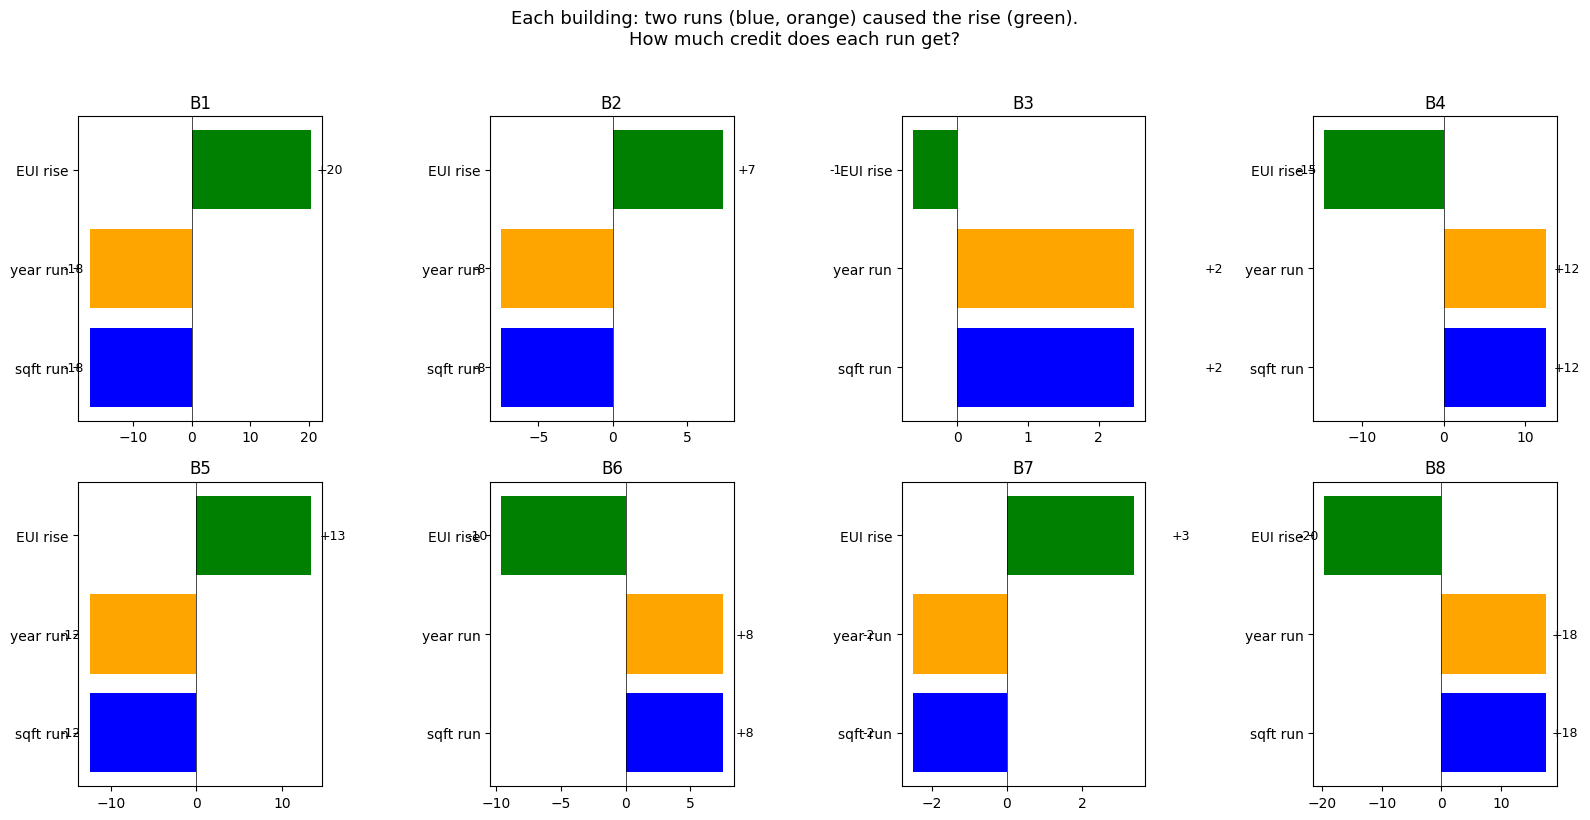

We want to find slope1 and slope2 such that:
  slope1 x blue bar + slope2 x orange bar ≈ green bar

  B1:  slope1 x  -17.5  +  slope2 x    -18  ≈   +20.4
  B2:  slope1 x   -7.5  +  slope2 x     -8  ≈    +7.4
  B3:  slope1 x   +2.5  +  slope2 x     +2  ≈    -0.6
  B4:  slope1 x  +12.5  +  slope2 x    +12  ≈   -14.6
  B5:  slope1 x  -12.5  +  slope2 x    -12  ≈   +13.4
  B6:  slope1 x   +7.5  +  slope2 x     +8  ≈    -9.6
  B7:  slope1 x   -2.5  +  slope2 x     -2  ≈    +3.4
  B8:  slope1 x  +17.5  +  slope2 x    +18  ≈   -19.6

8 equations, 2 unknowns (slope1 and slope2).
No pair of slopes will satisfy ALL 8 perfectly (the data has noise).
We want the pair that gets CLOSEST — smallest total squared error.


In [8]:
# Let's write out what we want:
#
# For each building:
#   slope1 x (its sqft run) + slope2 x (its year run) = its EUI rise
#
# 8 buildings = 8 equations, 2 unknowns

# Visualize: each building has two runs and one rise. How to split the credit?
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    ax.barh(['sqft run', 'year run', 'EUI rise'], 
            [runs_sqft[i], runs_year[i], rises[i]],
            color=['blue', 'orange', 'green'])
    ax.set_title(f'B{i+1}', fontsize=12)
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    # Label the bars
    for val, y in zip([runs_sqft[i], runs_year[i], rises[i]], [0, 1, 2]):
        ax.text(val + (1 if val >= 0 else -1), y, f'{val:+.0f}', 
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Each building: two runs (blue, orange) caused the rise (green).\nHow much credit does each run get?', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('We want to find slope1 and slope2 such that:')
print('  slope1 x blue bar + slope2 x orange bar ≈ green bar')
print()
for i in range(len(sqft)):
    print(f'  B{i+1}:  slope1 x {runs_sqft[i]:+6.1f}  +  slope2 x {runs_year[i]:+6.0f}  ≈  {rises[i]:+6.1f}')

print()
print('8 equations, 2 unknowns (slope1 and slope2).')
print('No pair of slopes will satisfy ALL 8 perfectly (the data has noise).')
print('We want the pair that gets CLOSEST — smallest total squared error.')

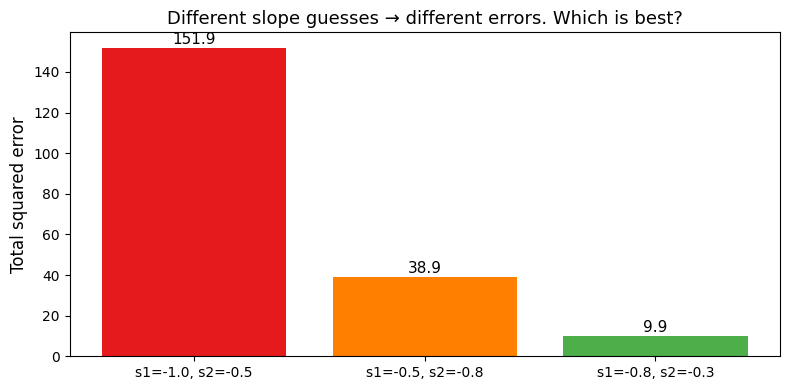

Different guesses give different errors.
There's one BEST pair out there — how do we find it without guessing?


In [9]:
# Let's try guessing some slopes and see how wrong they are

guesses = [
    (-1.0, -0.5),
    (-0.5, -0.8),
    (-0.8, -0.3),
]

errors_list = []
for s1, s2 in guesses:
    predictions = s1 * runs_sqft + s2 * runs_year
    errors = rises - predictions
    total_error = (errors ** 2).sum()
    errors_list.append(total_error)

fig, ax = plt.subplots(figsize=(8, 4))
labels = [f's1={s1}, s2={s2}' for s1, s2 in guesses]
bars = ax.bar(labels, errors_list, color=['#e41a1c', '#ff7f00', '#4daf4a'])
for bar, err in zip(bars, errors_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{err:.1f}', ha='center', fontsize=11)
ax.set_ylabel('Total squared error', fontsize=12)
ax.set_title('Different slope guesses → different errors. Which is best?', fontsize=13)
plt.tight_layout()
plt.show()

print('Different guesses give different errors.')
print('There\'s one BEST pair out there — how do we find it without guessing?')

## Chapter 6: The single-feature formula, revisited

Before we solve 2 features, let's look at what the 1-feature formula was really doing.

In [10]:
# With 1 feature, we had:
#   slope = sum(run x rise) / sum(run x run)
#
# Let's rewrite that differently.
# For each building, the equation was:
#   slope x run = rise    (approximately)
#
# We multiplied both sides by run:
#   slope x run x run = rise x run
#
# Then summed over all buildings:
#   slope x sum(run x run) = sum(rise x run)
#
# Then divided:
#   slope = sum(rise x run) / sum(run x run)
#
# That's our formula! It came from:
#   1. Write the equation for each building
#   2. Multiply both sides by the run
#   3. Add them all up
#   4. Solve for slope

print('The 1-feature formula came from 4 steps:')
print()
print('Step 1: For each building:  slope x run = rise')
print('Step 2: Multiply both sides by run:  slope x run² = rise x run')
print('Step 3: Add all buildings:  slope x sum(run²) = sum(rise x run)')
print('Step 4: Divide:  slope = sum(rise x run) / sum(run²)')
print()
print('Same formula as before, but now we see WHERE it came from.')
print('Can we do the same thing with 2 features?')

The 1-feature formula came from 4 steps:

Step 1: For each building:  slope x run = rise
Step 2: Multiply both sides by run:  slope x run² = rise x run
Step 3: Add all buildings:  slope x sum(run²) = sum(rise x run)
Step 4: Divide:  slope = sum(rise x run) / sum(run²)

Same formula as before, but now we see WHERE it came from.
Can we do the same thing with 2 features?


## Chapter 7: Doing the same thing with 2 features

Same 4 steps, but now there are 2 unknowns.

In [11]:
# Step 1: For each building:
#   slope1 x sqft_run + slope2 x year_run = rise
#
# Step 2: To isolate slope1, multiply both sides by sqft_run:
#   slope1 x sqft_run² + slope2 x year_run x sqft_run = rise x sqft_run
#
# Step 3: Add all buildings:
#   slope1 x sum(sqft_run²) + slope2 x sum(year_run x sqft_run) = sum(rise x sqft_run)
#
# That's ONE equation with TWO unknowns. Not enough!
# We need a second equation.

print('Multiply everything by sqft_run and add up:')
print()

a11 = (runs_sqft * runs_sqft).sum()
a12 = (runs_year * runs_sqft).sum()
b1  = (rises * runs_sqft).sum()

print(f'Equation 1:  slope1 x {a11:.0f}  +  slope2 x {a12:.0f}  =  {b1:.1f}')
print()
print('One equation, two unknowns. We need another equation.')

Multiply everything by sqft_run and add up:

Equation 1:  slope1 x 1050  +  slope2 x 1050  =  -1187.5

One equation, two unknowns. We need another equation.


In [12]:
# Do the same thing but multiply by year_run instead:
#
# Step 2b: Multiply both sides by year_run:
#   slope1 x sqft_run x year_run + slope2 x year_run² = rise x year_run
#
# Step 3b: Add all buildings:
#   slope1 x sum(sqft_run x year_run) + slope2 x sum(year_run²) = sum(rise x year_run)

a21 = (runs_sqft * runs_year).sum()
a22 = (runs_year * runs_year).sum()
b2  = (rises * runs_year).sum()

print(f'Equation 2:  slope1 x {a21:.0f}  +  slope2 x {a22:.0f}  =  {b2:.1f}')
print()
print('Now we have 2 equations and 2 unknowns!')
print()
print(f'  slope1 x {a11:.0f}  +  slope2 x {a12:.0f}  =  {b1:.1f}')
print(f'  slope1 x {a21:.0f}  +  slope2 x {a22:.0f}  =  {b2:.1f}')
print()
print('Two equations, two unknowns — solvable!')

Equation 2:  slope1 x 1050  +  slope2 x 1050  =  -1187.5

Now we have 2 equations and 2 unknowns!

  slope1 x 1050  +  slope2 x 1050  =  -1187.5
  slope1 x 1050  +  slope2 x 1050  =  -1187.5

Two equations, two unknowns — solvable!


In [13]:
# Solve the 2 equations
# We can use basic algebra: solve equation 1 for slope1, plug into equation 2
# Or we can let numpy do it:

A = np.array([[a11, a12],
              [a21, a22]])

b = np.array([b1, b2])

slopes = np.linalg.solve(A, b)

print('Solving the two equations...')
print()
print(f'slope1 (sqft effect):       {slopes[0]:.4f}')
print(f'slope2 (year_built effect): {slopes[1]:.4f}')
print()
print(f'Compare to the separate slopes:')
print(f'sqft alone:       {slope_sqft_alone:.4f}')
print(f'year_built alone: {slope_year_alone:.4f}')
print()
print('Different! The simultaneous slopes account for the overlap between features.')

LinAlgError: Singular matrix

In [ ]:
# Let's compare the errors

# Solve for simultaneous slopes first
A = np.array([[a11, a12],
              [a21, a22]])
b_vec = np.array([b1, b2])
slopes = np.linalg.solve(A, b_vec)

# Separate slopes (wrong way)
intercept_sep = avg_eui - slope_sqft_alone * avg_sqft - slope_year_alone * avg_year
pred_sep = slope_sqft_alone * sqft + slope_year_alone * year_built + intercept_sep
error_sep = ((eui - pred_sep) ** 2).sum()

# Simultaneous slopes (correct way)
intercept_sim = avg_eui - slopes[0] * avg_sqft - slopes[1] * avg_year
pred_sim = slopes[0] * sqft + slopes[1] * year_built + intercept_sim
error_sim = ((eui - pred_sim) ** 2).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot predictions vs actual for both methods
for ax, pred, error, title in [
    (axes[0], pred_sep, error_sep, 'Slopes found SEPARATELY'),
    (axes[1], pred_sim, error_sim, 'Slopes found TOGETHER'),
]:
    ax.scatter(eui, pred, color='steelblue', s=100, zorder=5)
    # Perfect prediction line
    ax.plot([40, 100], [40, 100], 'r--', linewidth=1, label='perfect prediction')
    for i in range(len(eui)):
        ax.plot([eui[i], eui[i]], [eui[i], pred[i]], 'gray', linestyle='--', linewidth=1)
        ax.annotate(f' B{i+1}', xy=(eui[i], pred[i]), fontsize=9)
    ax.set_xlabel('Actual EUI', fontsize=12)
    ax.set_ylabel('Predicted EUI', fontsize=12)
    ax.set_title(f'{title}\ntotal error = {error:.1f}', fontsize=11)
    ax.legend()

plt.tight_layout()
plt.show()

print(f'Separate slopes error: {error_sep:.1f}')
print(f'Together slopes error: {error_sim:.1f}')
print()
print('Finding slopes together gives lower error — better predictions.')
print('Points are closer to the red dashed line (perfect prediction).')

## Chapter 8: This IS the matrix equation

Those two equations we solved? That's what the matrix formula does — just written more compactly.

In [ ]:
# Our two equations were:
#   slope1 x sum(sqft_run²)           + slope2 x sum(year_run x sqft_run) = sum(rise x sqft_run)
#   slope1 x sum(sqft_run x year_run) + slope2 x sum(year_run²)           = sum(rise x year_run)
#
# Written as a grid:
#
#   | sum(sqft_run²)           sum(year_run x sqft_run) |   | slope1 |   | sum(rise x sqft_run) |
#   |                                                    | x |        | = |                       |
#   | sum(sqft_run x year_run) sum(year_run²)           |   | slope2 |   | sum(rise x year_run) |
#
# That grid of numbers is called a MATRIX.
# It's not a new concept — it's just a compact way to write multiple equations.

print('Our two equations, written as a grid:')
print()
print(f'  | {a11:8.0f}  {a12:8.0f} |   | slope1 |   | {b1:8.1f} |')
print(f'  |                    | x |        | = |          |')
print(f'  | {a21:8.0f}  {a22:8.0f} |   | slope2 |   | {b2:8.1f} |')
print()
print('The grid on the left is a MATRIX.')
print('It\'s not magic — it\'s just a way to organize the numbers')
print('from our equations so a computer can solve them.')
print()
print('Shorthand: A x slopes = b')
print('Solution:  slopes = solve(A, b)')

In [ ]:
# Where does this matrix come from?
# 
# Remember: we stacked our runs into columns.
# Each row is a building. Each column is a feature.

X = np.column_stack([runs_sqft, runs_year])

print('Our runs, organized as a table (matrix X):')
print()
print('Building | sqft run | year run')
print('-' * 35)
for i in range(len(sqft)):
    print(f'   B{i+1}    | {runs_sqft[i]:+7.1f}  | {runs_year[i]:+7.0f}')

print()
print('The matrix A = X transposed times X')
print('(each column multiplied with every column, summed over all buildings)')
print()

A_from_X = X.T @ X  # X transposed times X
b_from_X = X.T @ rises  # X transposed times rises

print(f'A = X.T @ X = ')
print(f'  | {A_from_X[0,0]:8.0f}  {A_from_X[0,1]:8.0f} |')
print(f'  | {A_from_X[1,0]:8.0f}  {A_from_X[1,1]:8.0f} |')
print()
print(f'b = X.T @ rises = [{b_from_X[0]:.1f}, {b_from_X[1]:.1f}]')
print()
print('Same numbers as before! The matrix formula is just organizing the same steps.')

In [ ]:
# Verify: solve using the matrix formula
slopes_matrix = np.linalg.solve(A_from_X, b_from_X)

print('Slopes from our step-by-step equations:', slopes)
print('Slopes from the matrix formula:        ', slopes_matrix)
print()
print('Identical! The matrix formula is just shorthand for what we already did.')

## Chapter 9: Why matrices matter — scaling to 83 features

With 2 features we had 2 equations. With 83 features we'd have 83 equations. Same idea, just bigger.

In [ ]:
print('With 1 feature:')
print('  1 equation, 1 unknown → slope = sum(rise x run) / sum(run²)')
print()
print('With 2 features:')
print('  2 equations, 2 unknowns → solve a 2x2 grid')
print()
print('With 83 features:')
print('  83 equations, 83 unknowns → solve an 83x83 grid')
print()
print('The steps are EXACTLY the same:')
print('  1. Stack all the runs into a table (matrix X)')
print('  2. Compute A = X.T @ X  (features multiplied with each other)')
print('  3. Compute b = X.T @ rises  (features multiplied with target)')
print('  4. Solve A @ slopes = b')
print()
print('A human couldn\'t solve 83 equations by hand.')
print('But numpy.linalg.solve does it in milliseconds.')
print('That\'s the only reason we use matrices — to scale up.')

## Summary

1. With 1 feature, we found 1 slope using the voting formula.
2. With 2+ features, we **can't** find slopes one at a time — features are tangled together. Finding sqft's slope alone might accidentally include year_built's effect.
3. The fix: write an equation for each building (`slope1 x run1 + slope2 x run2 = rise`), then solve all equations at once.
4. Multiplying both sides by each feature's run and summing gives us a system of equations — one per feature.
5. That system of equations, written as a grid, **is** the matrix equation: `X.T @ X @ slopes = X.T @ rises`.
6. Matrices aren't a new concept. They're just a compact way to write many equations so a computer can solve them all at once.
7. The same steps work for 2 features, 83 features, or 1000 features.